# Laptop Market Analysis
## Project Overview

This project explores the laptop market using exploratory data analysis (EDA), statistical methods, and feature engineering techniques.

The goal of the analysis is to identify which hardware and software characteristics have the strongest impact on customer ratings and overall user satisfaction.

## 1. Data Loading and Initial Exploration

### The dataset contains information about laptops, including:

- Brand
- Processor
- RAM
- Storage
- Operating system
- Display size
- Price
- Customer ratings
- Number of reviews

### Libraries Used:

- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Plotly

### Initial Exploration

Tasks performed:

- Loading the dataset
- Inspecting data types
- Checking dataset dimensions
- Reviewing missing values
- Exploring numerical statistics




In [9]:
# Importing libraries
import os
import re

import numpy as np
from scipy import stats
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

# Settings
sns.set_style('whitegrid')

In [10]:
# Downloading the data
path = kagglehub.dataset_download("rajugc/laptop-selection-dataset")

print("Path to dataset files:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)

print(f"\nLoaded file: {csv_files[0]}")
print(f"Dataset size: {df.shape}")

Using Colab cache for faster access to the 'laptop-selection-dataset' dataset.
Path to dataset files: /kaggle/input/laptop-selection-dataset

Loaded file: laptops.csv
Dataset size: (984, 12)


In [11]:
# Display the first 5 rows of the table
df.head()

,Unnamed: 0,img_link,name,price(in Rs.),processor,ram,os,storage,display(in inch),rating,no_of_ratings,no_of_reviews
0,0,https://rukminim1.flixcart.com/image/312/312/x...,Lenovo Intel Core i5 11th Gen,62990,Intel Core i5 Processor (11th Gen),16 GB DDR4 RAM,Windows 11 Operating System,512 GB SSD,15.6,4.5,14.0,1.0
1,1,https://rukminim1.flixcart.com/image/312/312/x...,Lenovo V15 G2 Core i3 11th Gen,37500,Intel Core i3 Processor (11th Gen),8 GB DDR4 RAM,64 bit Windows 11 Operating System,1 TB HDD|256 GB SSD,15.6,4.4,53.0,3.0
2,2,https://rukminim1.flixcart.com/image/312/312/l...,ASUS TUF Gaming F15 Core i5 10th Gen,49990,Intel Core i5 Processor (10th Gen),8 GB DDR4 RAM,Windows 11 Operating System,512 GB SSD,15.6,4.4,4733.0,463.0
3,3,https://rukminim1.flixcart.com/image/312/312/x...,ASUS VivoBook 15 (2022) Core i3 10th Gen,33990,Intel Core i3 Processor (10th Gen),8 GB DDR4 RAM,64 bit Windows 11 Operating System,512 GB SSD,15.6,4.3,10406.0,1040.0
4,4,https://rukminim1.flixcart.com/image/312/312/x...,Lenovo Athlon Dual Core,18990,AMD Athlon Dual Core Processor,4 GB DDR4 RAM,DOS Operating System,256 GB SSD,14.0,3.8,18.0,3.0


In [12]:
# Checking data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        984 non-null    int64  
 1   img_link          984 non-null    object 
 2   name              984 non-null    object 
 3   price(in Rs.)     984 non-null    int64  
 4   processor         984 non-null    object 
 5   ram               984 non-null    object 
 6   os                984 non-null    object 
 7   storage           984 non-null    object 
 8   display(in inch)  984 non-null    float64
 9   rating            688 non-null    float64
 10  no_of_ratings     688 non-null    float64
 11  no_of_reviews     688 non-null    float64
dtypes: float64(4), int64(2), object(6)
memory usage: 92.4+ KB


In [13]:
# Looking at statistics of numerical features
df.describe()

,Unnamed: 0,price(in Rs.),display(in inch),rating,no_of_ratings,no_of_reviews
count,984.000000,984.000000,984.000000,688.000000,688.000000,688.000000
mean,491.500000,80960.720528,15.148374,4.284884,718.091570,83.898256
std,284.200633,57421.220919,1.332078,0.330239,1750.817825,211.596726
min,0.000000,15990.000000,11.600000,1.600000,1.000000,0.000000
25%,245.750000,42655.000000,14.000000,4.100000,14.000000,2.000000
50%,491.500000,62990.000000,15.600000,4.300000,90.000000,11.000000
75%,737.250000,94990.000000,15.600000,4.500000,453.000000,53.500000
max,983.000000,419990.000000,35.000000,5.000000,15492.000000,2054.000000


### Initial Observations:

- The dataset contains both categorical and numerical features.
- Several columns require preprocessing and feature extraction.
- Some missing values and outliers are present.

## 2. Data Cleaning

In [14]:
df = df.drop(columns = ['Unnamed: 0', 'img_link'])

### Missing Values

Actions:

- Missing values in review counts were replaced with 0.
- Missing ratings were preserved to avoid distorting distributions.

In [15]:
print('Number of Missing Values:')
for col in df.columns:
    print(f'{col}: {df[col].isna().sum()} ({df[col].isna().sum()/df.shape[0]:.2%})')

Number of Missing Values:
name: 0 (0.00%)
price(in Rs.): 0 (0.00%)
processor: 0 (0.00%)
ram: 0 (0.00%)
os: 0 (0.00%)
storage: 0 (0.00%)
display(in inch): 0 (0.00%)
rating: 296 (30.08%)
no_of_ratings: 296 (30.08%)
no_of_reviews: 296 (30.08%)


In [16]:
fill_values = {col: 0 for col in df.columns if col != 'rating'}
df.fillna(fill_values, inplace=True)

### Duplicate Handling

Actions:

- Duplicate laptop configurations were identified.
- Review counts were aggregated.
- Ratings were recalculated using weighted averages.

In [17]:
df.duplicated().sum()

np.int64(212)

In [18]:
duplicates = df[df.duplicated(keep=False)]
print(f"\nFirst 5 Duplicated Rows:")
print(duplicates.head())


First 5 Duplicated Rows:
                                   name  price(in Rs.)  \
0         Lenovo Intel Core i5 11th Gen          62990   
1        Lenovo V15 G2 Core i3 11th Gen          37500   
5             APPLE 2020 Macbook Air M1          86990   
7   DELL Vostro Ryzen 3 Quad Core 5425U          36890   
15  realme Book (Slim) Core i3 11th Gen          46990   

                             processor             ram  \
0   Intel Core i5 Processor (11th Gen)  16 GB DDR4 RAM   
1   Intel Core i3 Processor (11th Gen)   8 GB DDR4 RAM   
5                   Apple M1 Processor   8 GB DDR4 RAM   
7      AMD Ryzen 3 Quad Core Processor   8 GB DDR4 RAM   
15  Intel Core i3 Processor (11th Gen)   8 GB DDR4 RAM   

                                    os              storage  display(in inch)  \
0          Windows 11 Operating System           512 GB SSD              15.6   
1   64 bit Windows 11 Operating System  1 TB HDD|256 GB SSD              15.6   
5              Mac OS Operating S

In [19]:
key_cols = ['name', 'processor', 'ram', 'storage', 'display(in inch)', 'os']

duplicates = df[df.duplicated(subset=key_cols, keep=False)]
print(duplicates.shape[0])

407


In [20]:
df['rating_weight'] = df['rating'] * df['no_of_ratings']

agg_df = df.groupby(key_cols, as_index=False).agg({
    'price(in Rs.)': 'mean',
    'no_of_ratings': 'sum',
    'no_of_reviews': 'sum',
    'rating_weight': 'sum'
})

# Recalculating the average rating
agg_df['rating'] = (agg_df['rating_weight'] / agg_df['no_of_ratings'])
agg_df.drop(columns='rating_weight', inplace=True)

In [21]:
agg_df.duplicated().sum()

np.int64(0)

### Outlier Detection

Examples:

- Incorrect display size values were corrected.

In [22]:
df.describe()

,price(in Rs.),display(in inch),rating,no_of_ratings,no_of_reviews,rating_weight
count,984.000000,984.000000,688.000000,984.000000,984.000000,688.000000
mean,80960.720528,15.148374,4.284884,502.080285,58.660569,3108.672238
std,57421.220919,1.332078,0.330239,1500.296392,181.033375,7684.314438
min,15990.000000,11.600000,1.600000,0.000000,0.000000,4.000000
25%,42655.000000,14.000000,4.100000,0.000000,0.000000,63.000000
50%,62990.000000,15.600000,4.300000,21.000000,3.000000,380.000000
75%,94990.000000,15.600000,4.500000,247.000000,22.000000,1947.900000
max,419990.000000,35.000000,5.000000,15492.000000,2054.000000,65066.400000


In [23]:
df['display(in inch)'].unique()

array([15.6 , 14.  , 13.3 , 17.3 , 13.6 , 17.  , 11.6 , 16.  , 16.1 ,
       13.4 , 16.2 , 14.2 , 14.5 , 14.1 , 14.96, 13.5 , 35.  , 16.6 ,
       15.  , 15.3 , 12.  ])

In [24]:
df[df['display(in inch)'] == 35.]

,name,price(in Rs.),processor,ram,os,storage,display(in inch),rating,no_of_ratings,no_of_reviews,rating_weight
594,DELL Vostro Core i5 11th Gen,63090,Intel Core i5 Processor (11th Gen),8 GB DDR4 RAM,64 bit Windows 10 Operating System,512 GB SSD,35.0,3.9,89.0,9.0,347.1
861,DELL Vostro Core i3 11th Gen,43090,Intel Core i3 Processor (11th Gen),4 GB DDR4 RAM,64 bit Windows 11 Operating System,1 TB HDD|256 GB SSD,35.0,4.2,33.0,7.0,138.6


In [25]:
# Replace 35.0 with 15.6 (the most probable value for DELL Vostro)
df.loc[df['display(in inch)'] == 35.0, 'display(in inch)'] = 15.6

### Key Result

The dataset became consistent and suitable for statistical analysis.

## 3. Feature Engineering
### Extracted Features

**RAM**
- Extracted RAM size in GB

**Storage**
- Total storage capacity
- Storage type (SSD / HDD / Hybrid)

**Processor**
- Processor brand
- Processor series
- Processor generation

**Operating System**
- Simplified OS categories

**Brand Extraction**
- Extracted laptop manufacturer names

**Display**
- Standardized display size values

### Final Dataset

The final dataset includes clean and analysis-ready features.

In [26]:
def process_full_dataset(df):
    """
    Function for processing dataset features
    """
    # Create a copy
    df_processed = df.copy()

    # Processing ram
    def extract_ram_gb(ram_str):
        if pd.isna(ram_str):
            return None
        match = re.search(r'(\d+)\s*GB', str(ram_str))
        return int(match.group(1)) if match else None

    df_processed['ram_gb'] = df_processed['ram'].apply(extract_ram_gb)

    # Processing storage
    def extract_total_storage_gb(storage_str):
        if pd.isna(storage_str):
            return None

        total_gb = 0
        storage_str = str(storage_str)

        matches = re.findall(r'(\d+)\s*(TB|GB|SSD|HDD)', storage_str, re.IGNORECASE)

        for num, unit in matches:
            num = int(num)
            unit_lower = unit.lower()
            if unit_lower == 'tb':
                num *= 1024
            total_gb += num

        if total_gb == 0:
            match = re.search(r'(\d+)', storage_str)
            if match:
                total_gb = int(match.group(1))

        return total_gb if total_gb > 0 else None

    df_processed['storage_gb'] = df_processed['storage'].apply(extract_total_storage_gb)

    # Processing os
    def simplify_os(os_str):
        if pd.isna(os_str):
            return 'Unknown'

        os_lower = str(os_str).lower()

        if 'windows 11' in os_lower:
            return 'Windows 11'
        elif 'windows 10' in os_lower:
            return 'Windows 10'
        elif 'mac' in os_lower or 'macos' in os_lower:
            return 'macOS'
        elif 'dos' in os_lower:
            return 'DOS'
        elif 'linux' in os_lower:
            return 'Linux'
        elif 'chrome' in os_lower:
            return 'Chrome OS'
        else:
            return 'Other'

    df_processed['os_simplified'] = df_processed['os'].apply(simplify_os)

    # Processing processor
    def extract_processor_brand(proc_str):
        if pd.isna(proc_str):
            return 'Unknown'
        proc_lower = str(proc_str).lower()
        if 'intel' in proc_lower:
            return 'Intel'
        elif 'amd' in proc_lower:
            return 'AMD'
        elif 'apple' in proc_lower or 'm1' in proc_lower or 'm2' in proc_lower or 'm3' in proc_lower:
            return 'Apple'
        else:
            return 'Other'

    def extract_processor_series(proc_str):
        if pd.isna(proc_str):
            return 'Unknown'
        proc_str = str(proc_str)

        match = re.search(r'Core\s+(i\d|i\d-\d+\w*)', proc_str, re.IGNORECASE)
        if match:
            return match.group(1)

        match = re.search(r'Ryzen\s+(\d+)', proc_str, re.IGNORECASE)
        if match:
            return f'Ryzen {match.group(1)}'

        if 'athlon' in proc_str.lower():
            return 'Athlon'

        match = re.search(r'A\d+', proc_str, re.IGNORECASE)
        if match:
            return match.group(0)

        if 'pentium' in proc_str.lower():
            return 'Pentium'
        if 'celeron' in proc_str.lower():
            return 'Celeron'

        return 'Other'

    def extract_generation(proc_str):
        if pd.isna(proc_str):
            return None

        proc_str = str(proc_str)

        # Intel
        match = re.search(r'\(?(\d+)(?:th|nd|rd|st)?\s*Gen\)?', proc_str, re.IGNORECASE)
        if match:
            return int(match.group(1))

        # AMD
        match = re.search(r'Ryzen\s+\d\s+(\d{4})[A-Z]*', proc_str, re.IGNORECASE)
        if match:
            series = int(match.group(1))
            return series // 1000

        if 'amd' in proc_str.lower() or 'ryzen' in proc_str.lower():
            match = re.search(r'(\d{4})', proc_str)
            if match:
                series = int(match.group(1))
                return series // 1000

        return None

    df_processed['processor_brand'] = df_processed['processor'].apply(extract_processor_brand)
    df_processed['processor_series'] = df_processed['processor'].apply(extract_processor_series)
    df_processed['processor_gen'] = df_processed['processor'].apply(extract_generation)

    # Extracting brand
    def extract_brand(name_str):
        if pd.isna(name_str):
            return 'Unknown'
        name_lower = str(name_str).lower()
        brands = [
            'lenovo', 'asus', 'dell', 'hp', 'apple', 'acer', 'msi',
            'realme', 'xiaomi', 'mi', 'samsung', 'lg', 'razer',
            'gigabyte', 'huawei', 'honor', 'oppo', 'vivo', 'infinix'
        ]
        for brand in brands:
            if brand in name_lower:
                return brand.capitalize()
        return 'Other'

    df_processed['brand'] = df_processed['name'].apply(extract_brand)

    # Storage type
    def extract_storage_type(storage_str):
        if pd.isna(storage_str):
            return 'Unknown'
        storage_lower = str(storage_str).lower()
        if 'ssd' in storage_lower and 'hdd' in storage_lower:
            return 'SSD+HDD'
        elif 'ssd' in storage_lower:
            return 'SSD'
        elif 'hdd' in storage_lower:
            return 'HDD'
        else:
            return 'Other'

    df_processed['storage_type'] = df_processed['storage'].apply(extract_storage_type)

    # Display size
    def extract_display_size(display_str):
        if pd.isna(display_str):
            return None
        match = re.search(r'(\d+\.?\d*)', str(display_str))
        return float(match.group(1)) if match else None

    df_processed['display_size'] = df_processed['display(in inch)'].apply(extract_display_size)

    # Filling missing values
    # processor_gen
    df_processed['processor_gen'] = df_processed['processor_gen'].fillna(-1)
    df_processed['processor_gen'] = df_processed['processor_gen'].astype(int)

    # storage_gb
    median_storage = df_processed['storage_gb'].median()
    df_processed['storage_gb'] = df_processed['storage_gb'].fillna(median_storage)
    df_processed['storage_gb'] = df_processed['storage_gb'].astype(int)

    # display_size
    median_display = df_processed['display_size'].median()
    df_processed['display_size'] = df_processed['display_size'].fillna(median_display)

    # Binary rating feature
    df_processed['has_rating'] = (df_processed['rating'] > 0).astype(int)

    final_columns = [
        'brand', 'price(in Rs.)', 'rating', 'no_of_ratings', 'no_of_reviews',
        'processor_brand', 'processor_series', 'processor_gen',
        'ram_gb', 'storage_gb', 'storage_type', 'os_simplified', 'display_size',
        'has_rating'
    ]

    df_final = df_processed[final_columns].copy()

    df_final = df_final.rename(columns={'os_simplified': 'os'})

    print(f"\nFinal size: {df_final.shape}")
    print(f"Missing values: {df_final.isna().sum().sum()}")

    return df_final

In [27]:
df_clean = process_full_dataset(agg_df)

print("\nInformation about the processed dataset:")
print(df_clean.info())
print(f"\nFirst 5 rows:")
print(df_clean.head())


Final size: (692, 14)
Missing values: 222

Information about the processed dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692 entries, 0 to 691
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             692 non-null    object 
 1   price(in Rs.)     692 non-null    float64
 2   rating            470 non-null    float64
 3   no_of_ratings     692 non-null    float64
 4   no_of_reviews     692 non-null    float64
 5   processor_brand   692 non-null    object 
 6   processor_series  692 non-null    object 
 7   processor_gen     692 non-null    int64  
 8   ram_gb            692 non-null    int64  
 9   storage_gb        692 non-null    int64  
 10  storage_type      692 non-null    object 
 11  os                692 non-null    object 
 12  display_size      692 non-null    float64
 13  has_rating        692 non-null    int64  
dtypes: float64(5), int64(4), object(5)
memory usage: 75.8

## 4. Statistical Analysis
### Distribution Analysis

Analyzed:
- Mean
- Median
- Standard deviation
- Skewness
- Kurtosis

In [29]:
numeric_features = ['price(in Rs.)', 'rating', 'no_of_ratings',	'no_of_reviews',
                    'processor_gen', 'ram_gb',	'storage_gb', 'display_size', 'has_rating']
categorical_cols = ['brand', 'processor_brand', 'processor_series', 'storage_type', 'os']

In [30]:
df_clean.describe()

,price(in Rs.),rating,no_of_ratings,no_of_reviews,processor_gen,ram_gb,storage_gb,display_size,has_rating
count,692.000000,470.000000,692.000000,692.000000,692.000000,692.000000,692.000000,692.000000,692.000000
mean,88130.711354,4.261142,713.940751,83.413295,6.359827,11.947977,675.712428,15.135116,0.679191
std,62067.327898,0.359658,3500.124883,389.490851,5.808747,6.201411,370.468612,1.499611,0.467125
min,15990.000000,1.600000,0.000000,0.000000,-1.000000,4.000000,4.000000,11.600000,0.000000
25%,45969.750000,4.079167,0.000000,0.000000,-1.000000,8.000000,512.000000,14.000000,0.000000
50%,68545.000000,4.300000,19.000000,3.000000,10.000000,8.000000,512.000000,15.600000,1.000000
75%,105990.000000,4.500000,229.250000,28.000000,11.000000,16.000000,1024.000000,15.600000,1.000000
max,419990.000000,5.000000,65212.000000,6286.000000,13.000000,32.000000,4096.000000,35.000000,1.000000


In [31]:
df_clean['storage_gb'].unique()

array([1024,  512,  256,  128, 2048, 1280, 4096, 1152,    5, 1536,    4])

In [32]:
df_clean[(df_clean['storage_gb'] == 4) | (df_clean['storage_gb'] == 5)]

,brand,price(in Rs.),rating,no_of_ratings,no_of_reviews,processor_brand,processor_series,processor_gen,ram_gb,storage_gb,storage_type,os,display_size,has_rating
580,Msi,98990.0,4.5,413.0,63.0,AMD,Ryzen 7,-1,16,5,SSD,Windows 10,15.6,1
616,Msi,74990.0,4.5,11.0,1.0,Intel,i5,11,16,4,SSD,Windows 10,14.0,1


In [35]:
df_clean[df_clean['storage_gb'] == 4096]

,brand,price(in Rs.),rating,no_of_ratings,no_of_reviews,processor_brand,processor_series,processor_gen,ram_gb,storage_gb,storage_type,os,display_size,has_rating
98,Asus,399990.0,NaN,0.0,0.0,Intel,i9,12,32,4096,SSD,Windows 11,17.3,0


In [36]:
# Replacement with plausible values
df_clean.loc[df_clean['storage_gb'] == 4, 'storage_gb'] = 512
df_clean.loc[df_clean['storage_gb'] == 5, 'storage_gb'] = 512


price(in Rs.):
  Skewness: 1.91
  Kurtosis: 4.47
  Conclusion: highly asymmetric distribution, right-skewed (positive) skewness

rating:
  Skewness: -1.17
  Kurtosis: 6.40
  Conclusion: highly asymmetric distribution, left-skewed (negative) skewness

no_of_ratings:
  Skewness: 12.29
  Kurtosis: 192.23
  Conclusion: highly asymmetric distribution, right-skewed (positive) skewness

no_of_reviews:
  Skewness: 11.31
  Kurtosis: 156.75
  Conclusion: highly asymmetric distribution, right-skewed (positive) skewness

processor_gen:
  Skewness: -0.42
  Kurtosis: -1.73
  Conclusion: symmetric distribution, left-skewed (negative) skewness

ram_gb:
  Skewness: 1.43
  Kurtosis: 2.64
  Conclusion: highly asymmetric distribution, right-skewed (positive) skewness

storage_gb:
  Skewness: 2.21
  Kurtosis: 11.80
  Conclusion: highly asymmetric distribution, right-skewed (positive) skewness

display_size:
  Skewness: 6.46
  Kurtosis: 87.77
  Conclusion: highly asymmetric distribution, right-skewed (posi

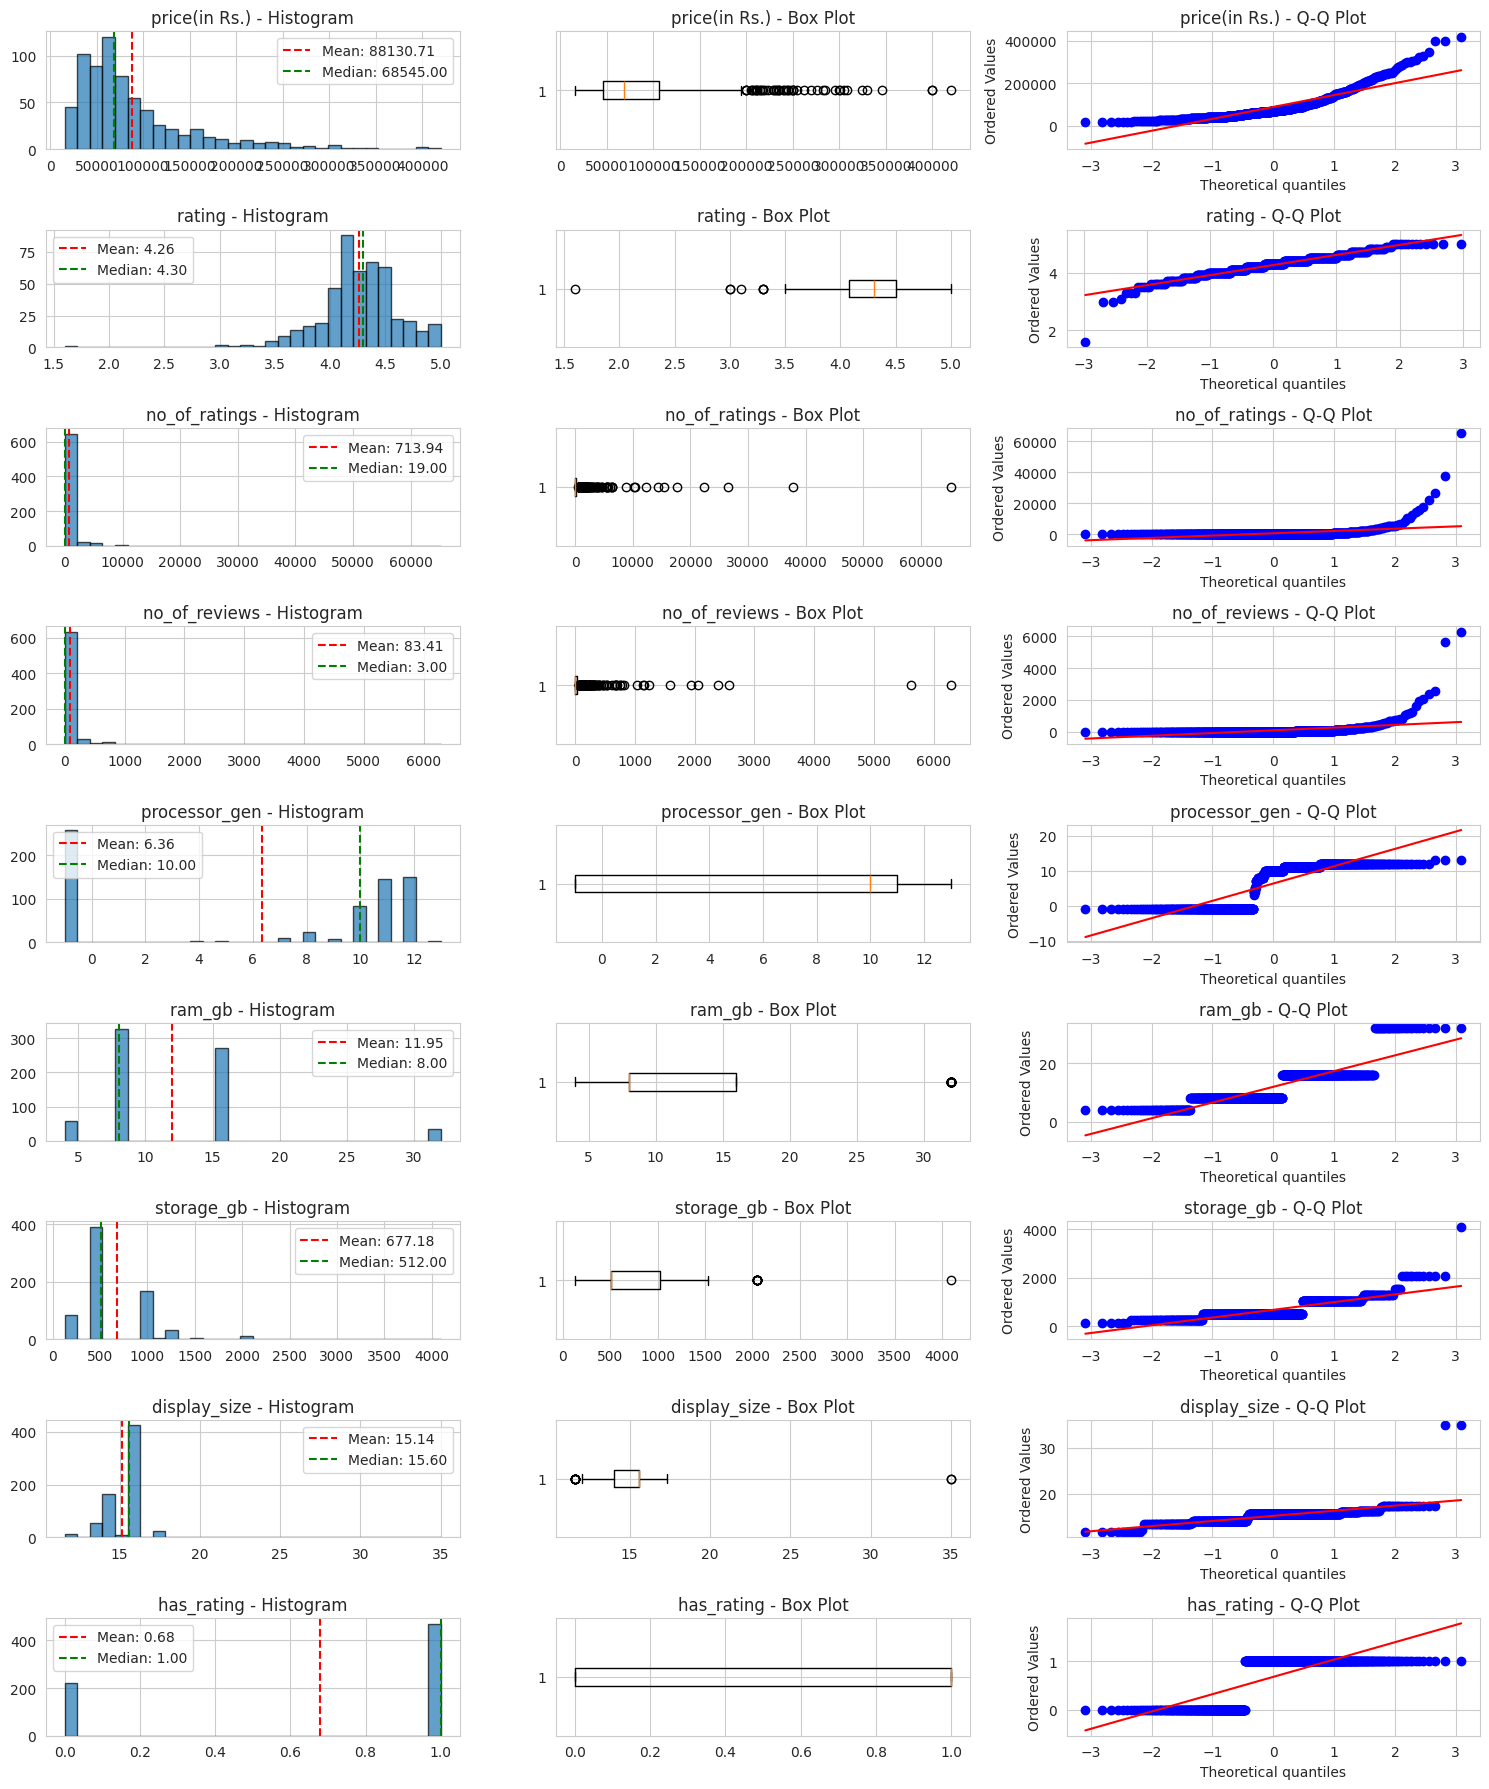

In [37]:
# Skewness and Kurtosis
for col in numeric_features:
    skewness = df_clean[col].skew()
    kurtosis = df_clean[col].kurtosis()

    print(f"\n{col}:")
    print(f"  Skewness: {skewness:.2f}")
    print(f"  Kurtosis: {kurtosis:.2f}")

    if abs(skewness) < 0.5:
        symm = "symmetric"
    elif abs(skewness) < 1:
        symm = "moderately asymmetric"
    else:
        symm = "highly asymmetric"

    # Direction of skewness
    if skewness > 0:
        direction = "right-skewed (positive)"
    elif skewness < 0:
        direction = "left-skewed (negative)"
    else:
        direction = "zero"

    print(f"  Conclusion: {symm} distribution, {direction} skewness")

# Outliers (IQR method)
outliers_summary = {}

for col in numeric_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df_clean)) * 100

    outliers_summary[col] = {
        'count': outlier_count,
        'percent': outlier_percent,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'min_val': df_clean[col].min(),
        'max_val': df_clean[col].max()
    }

    print(f"\n{col}:")
    print(f"  Normal range: [{lower_bound:.3f}, {upper_bound:.3f}]")
    print(f"  Outliers: {outlier_count} ({outlier_percent:.2f}%)")

    if outlier_count > 0:
        print(f"  Minimum value: {df_clean[col].min():.3f}")
        print(f"  Maximum value: {df_clean[col].max():.3f}")
        if df_clean[col].min() < lower_bound:
            print(f"  Lower outliers: {(df_clean[col] < lower_bound).sum()}")
        if df_clean[col].max() > upper_bound:
            print(f"  Upper outliers: {(df_clean[col] > upper_bound).sum()}")

# Visualization
fig, axes = plt.subplots(9, 3, figsize=(15, 18))

for i, col in enumerate(numeric_features):
    # Histogram
    axes[i, 0].hist(df_clean[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i, 0].axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[col].mean():.2f}')
    axes[i, 0].axvline(df_clean[col].median(), color='green', linestyle='--', label=f'Median: {df_clean[col].median():.2f}')
    axes[i, 0].set_title(f'{col} - Histogram')
    axes[i, 0].legend()

    # Box plot
    axes[i, 1].boxplot(df_clean[col].dropna(), vert=False)
    axes[i, 1].set_title(f'{col} - Box Plot')

    # Q-Q plot
    stats.probplot(df_clean[col].dropna(), dist="norm", plot=axes[i, 2])
    axes[i, 2].set_title(f'{col} - Q-Q Plot')

plt.tight_layout()
plt.show()

In [38]:
df_clean.describe(include='object')

,brand,processor_brand,processor_series,storage_type,os
count,692,692,692,692,692
unique,14,4,13,3,6
top,Asus,Intel,i5,SSD,Windows 11
freq,199,456,176,614,456


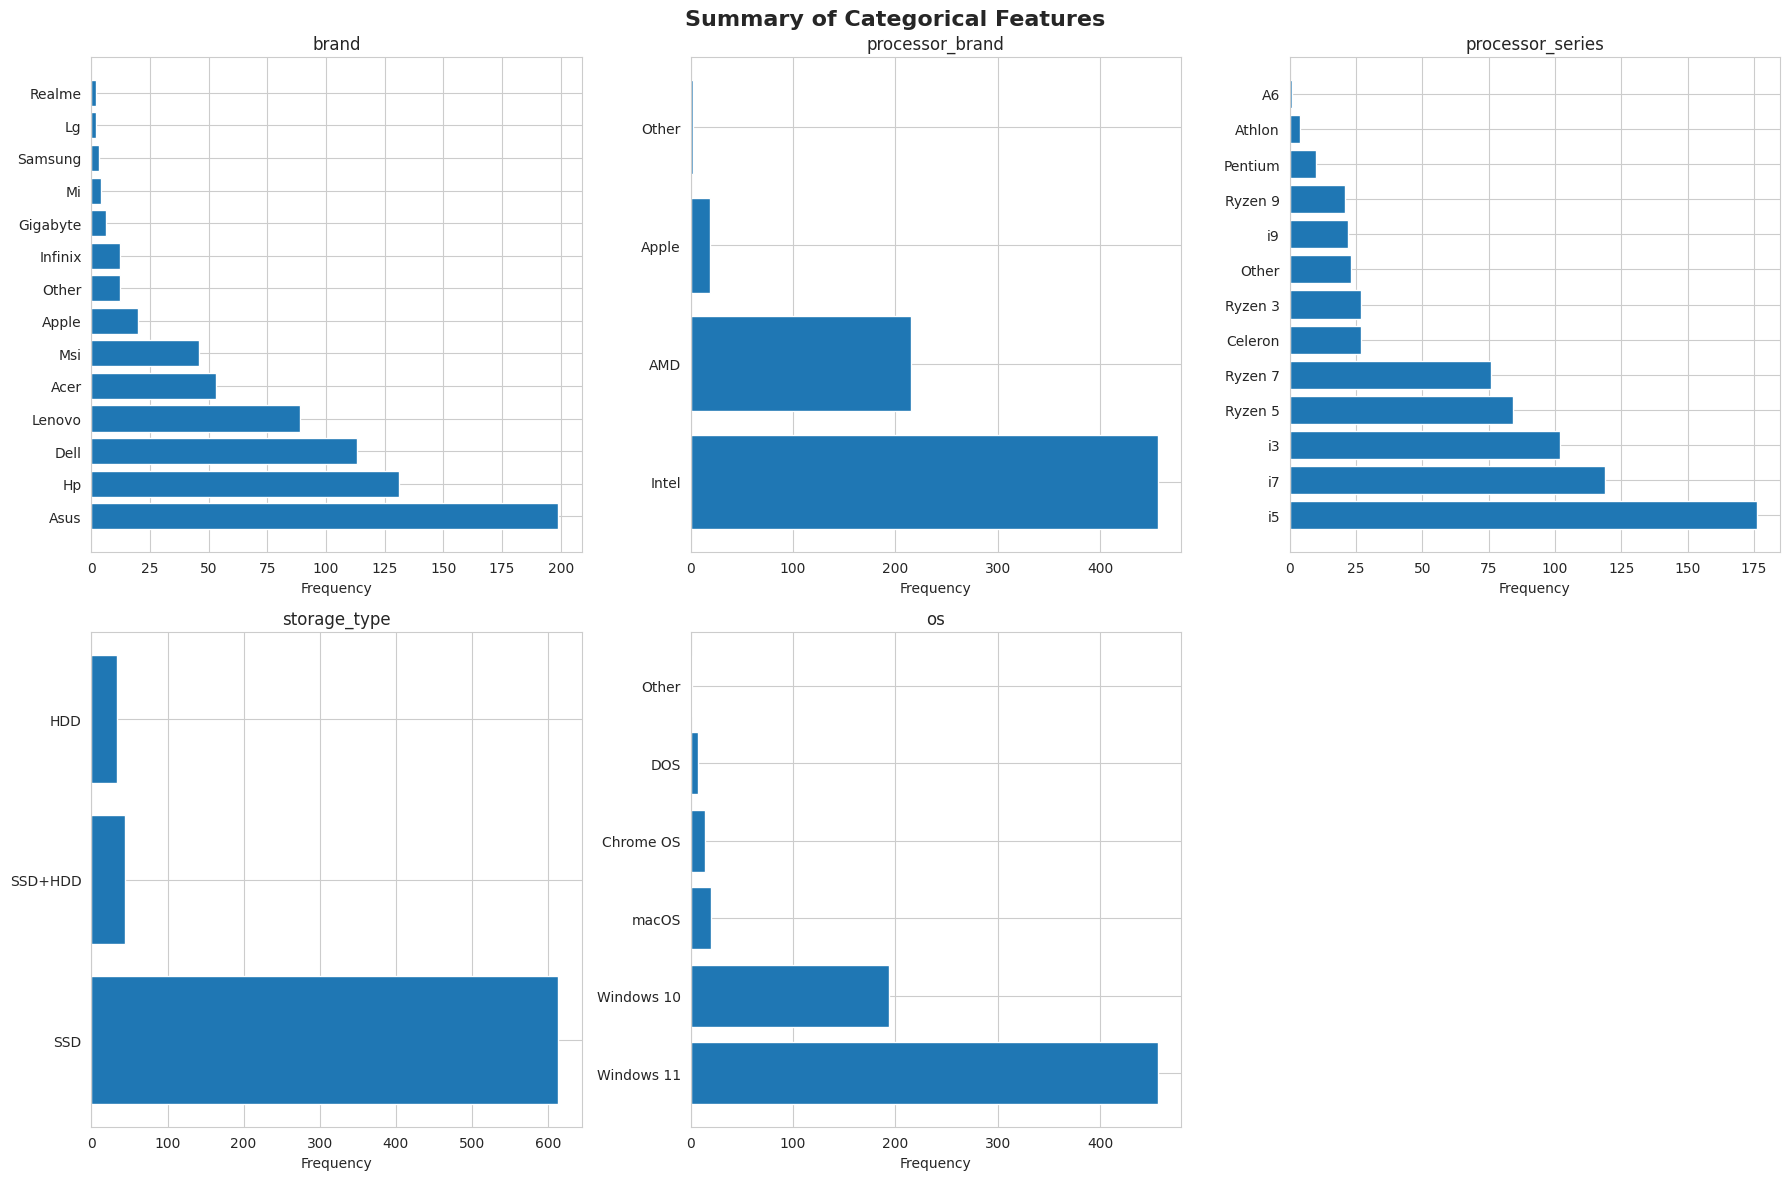

In [59]:
# Analysis of categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = df_clean[col].value_counts(dropna=False)
    axes[i].barh(range(len(value_counts)), value_counts.values)
    axes[i].set_yticks(range(len(value_counts)))
    axes[i].set_yticklabels(value_counts.index)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Frequency')

for i in range(len(categorical_cols), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Summary of Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
target = df_clean['rating'][df_clean['rating'] > 0]
target.describe()

,rating
count,470.000000
mean,4.261142
std,0.359658
min,1.600000
25%,4.079167
50%,4.300000
75%,4.500000
max,5.000000


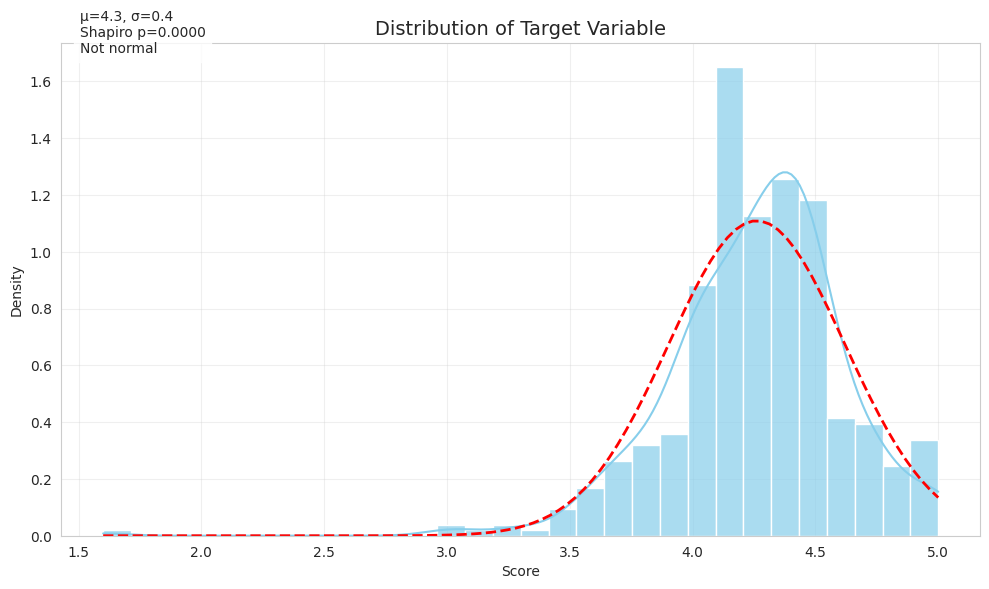

In [42]:
# Distribution plot of the target variable
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
sns.histplot(target, bins=30, kde=True, stat='density',
             color='skyblue', alpha=0.7)

# Normal curve
mu, std = target.mean(), target.std()
x = np.linspace(target.min(), target.max(), 100)
y = stats.norm.pdf(x, mu, std)
ax.plot(x, y, 'r--', linewidth=2)

# Normality test
_, p_val = stats.shapiro(target)

# Statistics
stats_text = f'μ={mu:.1f}, σ={std:.1f}\n'
stats_text += f'Shapiro p={p_val:.4f}\n'
stats_text += f'{"Normal" if p_val > 0.05 else "Not normal"}'

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

ax.set_title('Distribution of Target Variable', fontsize=14)
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

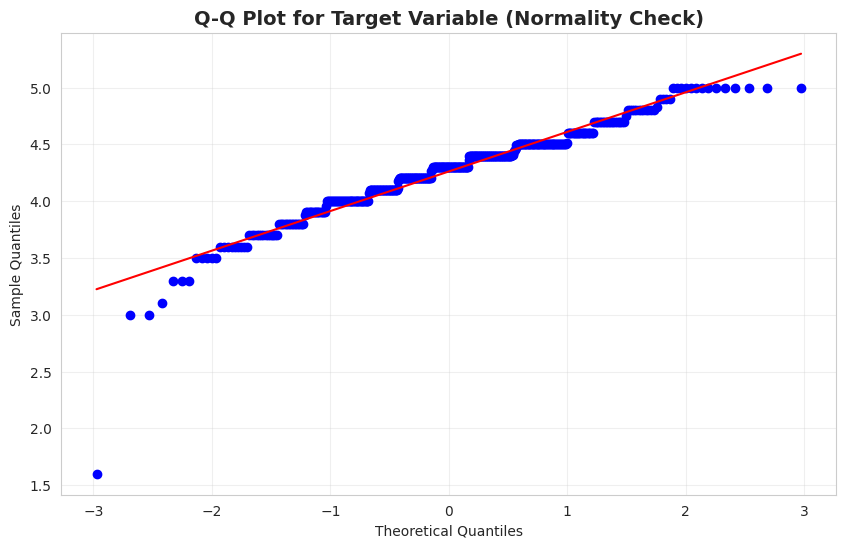

In [43]:
# Q-Q plot for the target variable
plt.figure(figsize=(10, 6))
stats.probplot(target, dist="norm", plot=plt)
plt.title(f'Q-Q Plot for Target Variable (Normality Check)', fontsize=14, fontweight='bold')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True, alpha=0.3)
plt.show()

### Outlier Analysis

The IQR method was used to identify extreme values.

**Key Findings**
- Price distribution is strongly right-skewed.
- Review counts contain long-tail distributions.
- Ratings are concentrated within a narrow range.

**Important Observation**
- Exact rating prediction may not be practical due to limited rating variance.
- A classification approach would likely be more effective.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Operating System Analysis

**Findings**
- macOS devices receive the highest ratings.
- Windows 11 dominates the market.
- DOS and Chrome OS devices have lower satisfaction scores.

In [44]:
# Filter only products with a real (non-zero) rating
df_rated = df_clean[df_clean['rating'] > 0].copy()

print(f"Total products with rating: {len(df_rated)}")
print(f"Percentage of total: {len(df_rated)/len(df_clean)*100:.1f}%")

Total products with rating: 470
Percentage of total: 67.9%


Rating by Operating System
            mean  count   std
os                           
macOS       4.63     15  0.18
Windows 11  4.28    280  0.31
Windows 10  4.25    155  0.42
Chrome OS   3.93     14  0.31
Other       3.80      1   NaN
DOS         3.74      5  0.18


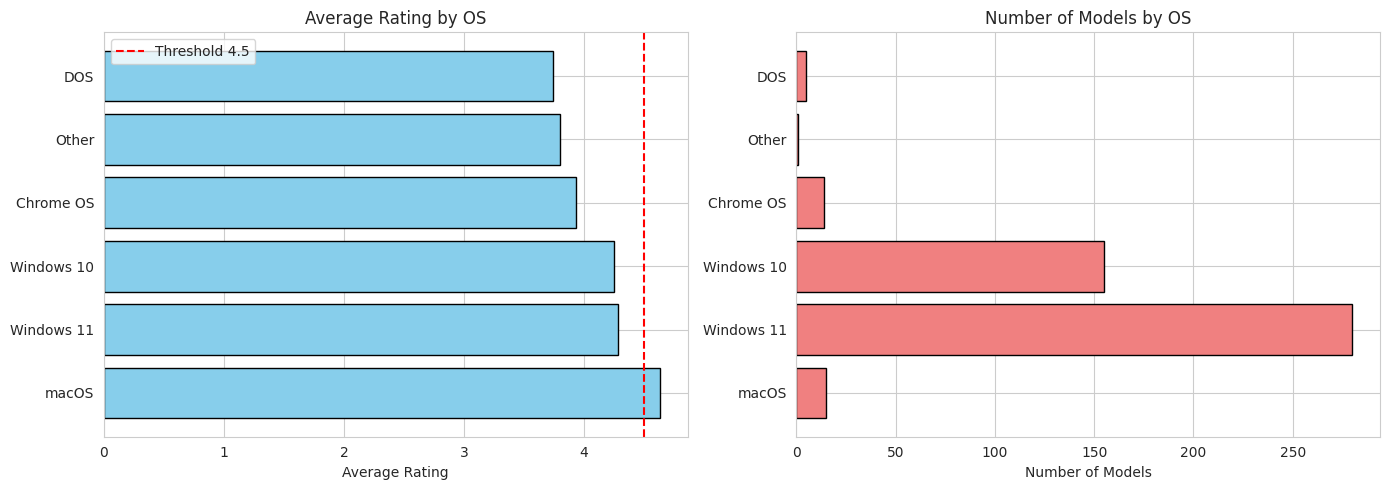

In [45]:
# Average rating by OS
os_rating = df_rated.groupby('os')['rating'].agg(['mean', 'count', 'std']).round(2)
os_rating = os_rating.sort_values('mean', ascending=False)

print("Rating by Operating System")
print(os_rating)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(os_rating.index, os_rating['mean'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Average Rating')
axes[0].set_title('Average Rating by OS')
axes[0].axvline(x=4.5, color='red', linestyle='--', label='Threshold 4.5')
axes[0].legend()

axes[1].barh(os_rating.index, os_rating['count'], color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Number of Models')
axes[1].set_title('Number of Models by OS')

plt.tight_layout()
plt.show()

### 5.2 Processor Analysis

**Findings**
- Apple processors achieve the highest ratings.
- AMD performs better than Intel in average customer satisfaction.
- More powerful processor series generally receive higher ratings.

Rating by processor brand
                 mean  count
processor_brand             
Apple            4.66     14
AMD              4.34    139
Intel            4.21    315
Other            4.00      2

Top 10 processor series by rating
                  mean  count
processor_series             
i9                4.63     11
Other             4.52     18
Ryzen 7           4.45     36
Ryzen 9           4.39      8
Ryzen 5           4.35     65
i7                4.29     60
Ryzen 3           4.24     23
i5                4.23    129
i3                4.16     86
Pentium           4.10      6


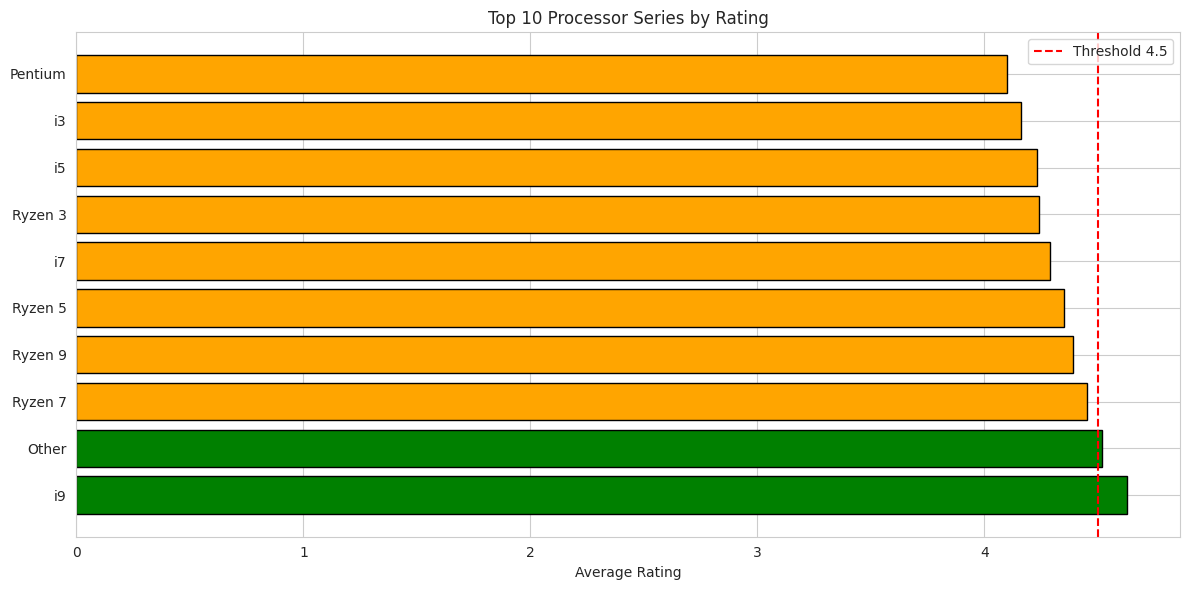

In [46]:
# Rating by processor brand
cpu_brand_rating = df_rated.groupby('processor_brand')['rating'].agg(['mean', 'count']).round(2)
cpu_brand_rating = cpu_brand_rating.sort_values('mean', ascending=False)

print("Rating by processor brand")
print(cpu_brand_rating)

# Analysis by processor series (top 10)
cpu_series_rating = df_rated.groupby('processor_series')['rating'].agg(['mean', 'count']).round(2)
cpu_series_rating = cpu_series_rating[cpu_series_rating['count'] >= 5]
cpu_series_rating = cpu_series_rating.sort_values('mean', ascending=False)

print("\nTop 10 processor series by rating")
print(cpu_series_rating.head(10))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
top_cpu = cpu_series_rating.head(10)
colors = ['green' if x >= 4.5 else 'orange' for x in top_cpu['mean']]
ax.barh(range(len(top_cpu)), top_cpu['mean'], color=colors, edgecolor='black')
ax.set_yticks(range(len(top_cpu)))
ax.set_yticklabels(top_cpu.index)
ax.set_xlabel('Average Rating')
ax.set_title('Top 10 Processor Series by Rating')
ax.axvline(x=4.5, color='red', linestyle='--', label='Threshold 4.5')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 RAM Analysis

**Findings**
- Higher RAM strongly correlates with higher ratings.
- 16 GB appears to be the optimal configuration.
- 4 GB devices receive the lowest ratings.

Rating by RAM size
         mean  count    std
ram_gb                     
4       4.031     49  0.282
8       4.226    263  0.343
16      4.381    151  0.363
32      4.629      7  0.236


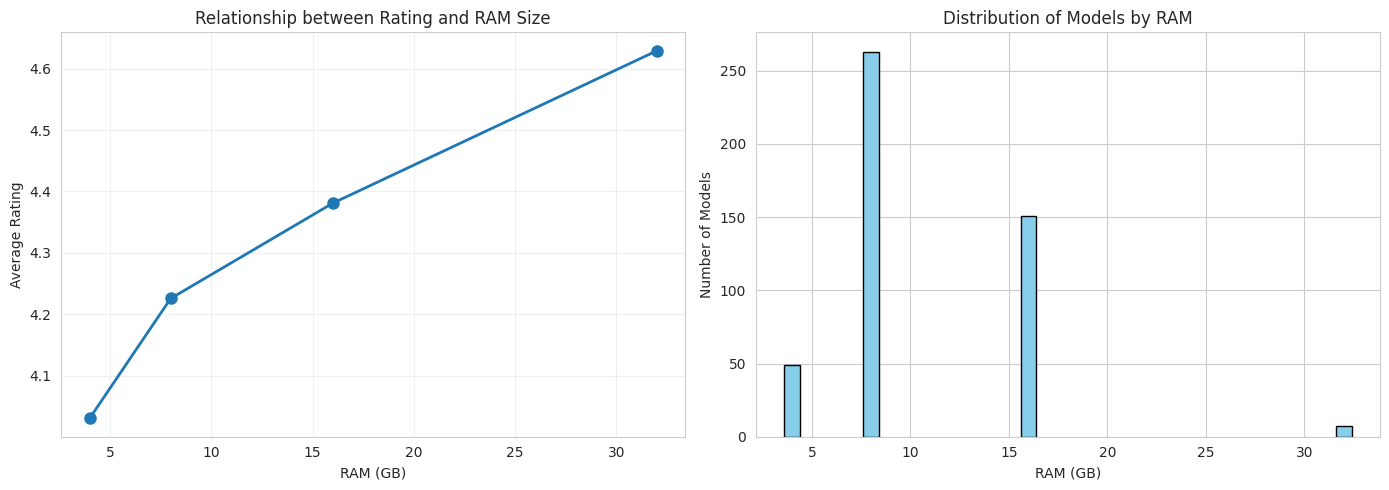

In [47]:
# Rating by RAM size
ram_rating = df_rated.groupby('ram_gb')['rating'].agg(['mean', 'count', 'std']).round(3)
ram_rating = ram_rating.sort_index()

print("Rating by RAM size")
print(ram_rating)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ram_rating.index, ram_rating['mean'], 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('RAM (GB)')
axes[0].set_ylabel('Average Rating')
axes[0].set_title('Relationship between Rating and RAM Size')
axes[0].grid(True, alpha=0.3)

axes[1].bar(ram_rating.index, ram_rating['count'], color='skyblue', edgecolor='black')
axes[1].set_xlabel('RAM (GB)')
axes[1].set_ylabel('Number of Models')
axes[1].set_title('Distribution of Models by RAM')

plt.tight_layout()
plt.show()

### 5.4 Storage Analysis

**Findings**
- SSD storage significantly outperforms HDD.
- 512 GB storage provides the best balance.
- Increasing storage beyond 512 GB does not improve ratings substantially.

Rating by storage size
                   mean  count
storage_category              
<256 GB           3.880      5
256-511 GB        4.232     63
512 GB            4.296    283
1 TB              4.220    115
>1 TB             3.925      4


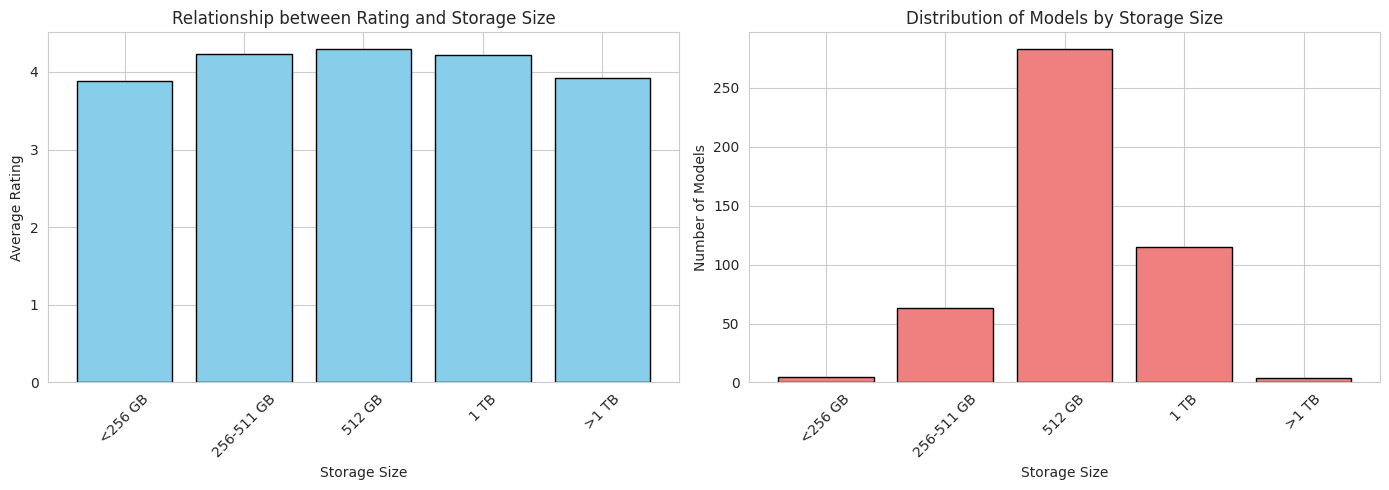

In [48]:
# Rating by storage size
def storage_category(gb):
    if gb < 256:
        return '<256 GB'
    elif gb < 512:
        return '256-511 GB'
    elif gb < 1024:
        return '512 GB'
    elif gb < 2048:
        return '1 TB'
    else:
        return '>1 TB'

df_rated['storage_category'] = df_rated['storage_gb'].apply(storage_category)

storage_rating = df_rated.groupby('storage_category')['rating'].agg(['mean', 'count']).round(3)
storage_rating = storage_rating.reindex(['<256 GB', '256-511 GB', '512 GB', '1 TB', '>1 TB'])

print("Rating by storage size")
print(storage_rating)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(storage_rating.index, storage_rating['mean'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Storage Size')
axes[0].set_ylabel('Average Rating')
axes[0].set_title('Relationship between Rating and Storage Size')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(storage_rating.index, storage_rating['count'], color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Storage Size')
axes[1].set_ylabel('Number of Models')
axes[1].set_title('Distribution of Models by Storage Size')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Rating by storage type
               mean  count
storage_type              
SSD           4.295    408
SSD+HDD       4.197     33
HDD           3.859     29


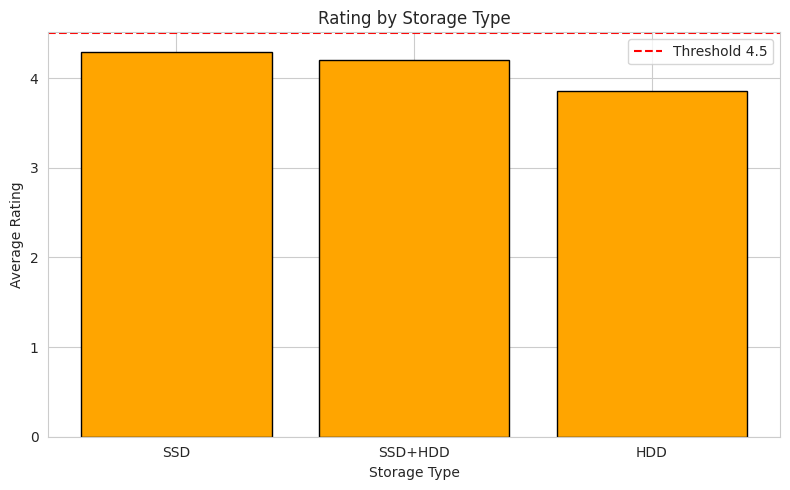

In [49]:
# Rating by storage type
storage_type_rating = df_rated.groupby('storage_type')['rating'].agg(['mean', 'count']).round(3)
storage_type_rating = storage_type_rating.sort_values('mean', ascending=False)

print("Rating by storage type")
print(storage_type_rating)

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['green' if x >= 4.5 else 'orange' for x in storage_type_rating['mean']]
ax.bar(storage_type_rating.index, storage_type_rating['mean'], color=colors, edgecolor='black')
ax.set_xlabel('Storage Type')
ax.set_ylabel('Average Rating')
ax.set_title('Rating by Storage Type')
ax.axhline(y=4.5, color='red', linestyle='--', label='Threshold 4.5')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Display Analysis

**Findings**
- Premium ultrabooks with 13–14 inch displays receive the highest ratings.
- 15.6 inch laptops dominate the mass market.

Rating by display diagonal size
                   mean  count
display_category              
<13"              3.833    9.0
13-13.9"          4.351   29.0
14-14.9"          4.243  120.0
15-15.9"          4.252  284.0
16"+                NaN    NaN


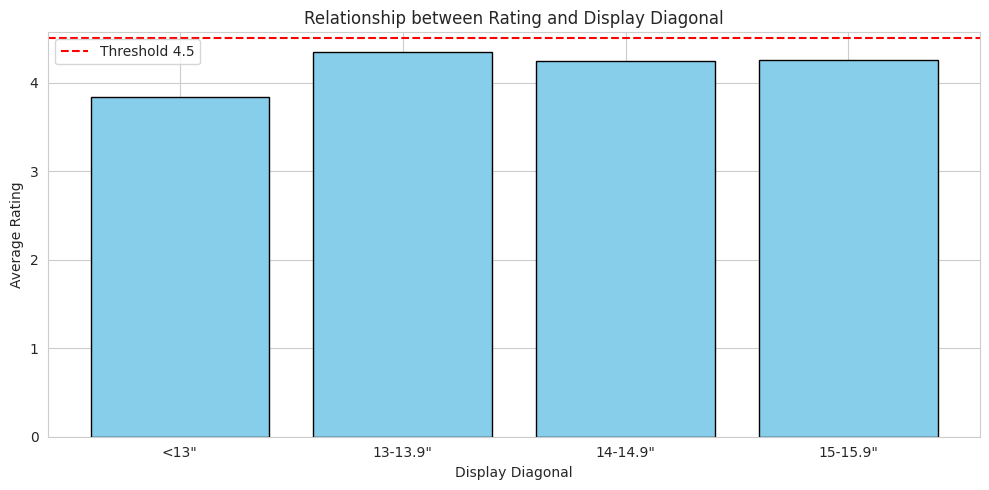

In [50]:
# Rating by display diagonal size
def display_category(inch):
    if inch < 13:
        return '<13"'
    elif inch < 14:
        return '13-13.9"'
    elif inch < 15:
        return '14-14.9"'
    elif inch < 16:
        return '15-15.9"'
    else:
        return '16"+"'

df_rated['display_category'] = df_rated['display_size'].apply(display_category)

display_rating = df_rated.groupby('display_category')['rating'].agg(['mean', 'count']).round(3)
display_rating = display_rating.reindex(['<13"', '13-13.9"', '14-14.9"', '15-15.9"', '16"+'])

print("Rating by display diagonal size")
print(display_rating)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(display_rating.index, display_rating['mean'], color='skyblue', edgecolor='black')
ax.set_xlabel('Display Diagonal')
ax.set_ylabel('Average Rating')
ax.set_title('Relationship between Rating and Display Diagonal')
ax.axhline(y=4.5, color='red', linestyle='--', label='Threshold 4.5')
ax.legend()
plt.tight_layout()
plt.show()

### 5.6 Brand Analysis

**Findings**
- Apple leads the premium segment.
- Asus and Acer perform strongly in the mass market.
- MSI receives high ratings in the gaming category.

Top 10 brands by rating
          mean  count
brand                
Apple    4.626     15
Msi      4.402     31
Samsung  4.333      3
Acer     4.309     45
Asus     4.307    132
Hp       4.245     84
Infinix  4.190     10
Lenovo   4.173     61
Dell     4.139     73
Mi       4.075      4


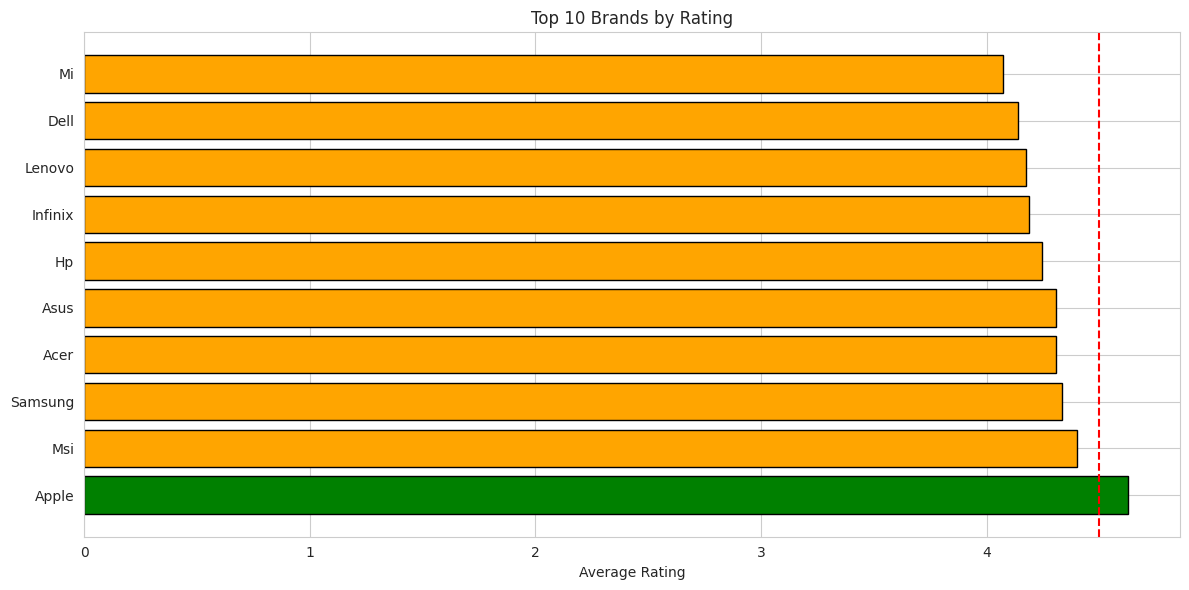

In [51]:
# Rating by brand
brand_rating = df_rated.groupby('brand')['rating'].agg(['mean', 'count']).round(3)
brand_rating = brand_rating[brand_rating['count'] >= 3]
brand_rating = brand_rating.sort_values('mean', ascending=False)

print("Top 10 brands by rating")
print(brand_rating.head(10))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
top_brands = brand_rating.head(10)
colors = ['green' if x >= 4.5 else 'orange' for x in top_brands['mean']]
ax.barh(range(len(top_brands)), top_brands['mean'], color=colors, edgecolor='black')
ax.set_yticks(range(len(top_brands)))
ax.set_yticklabels(top_brands.index)
ax.set_xlabel('Average Rating')
ax.set_title('Top 10 Brands by Rating')
ax.axvline(x=4.5, color='red', linestyle='--')
plt.tight_layout()
plt.show()

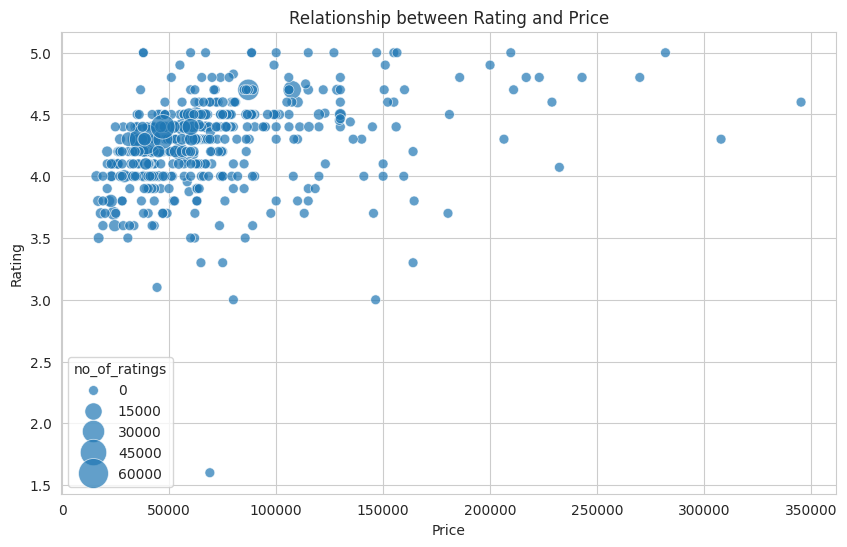

In [52]:
# Price vs Rating plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='price(in Rs.)',
    y='rating',
    size='no_of_ratings',
    sizes=(50, 500),
    alpha=0.7
)

plt.title('Relationship between Rating and Price')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.show()

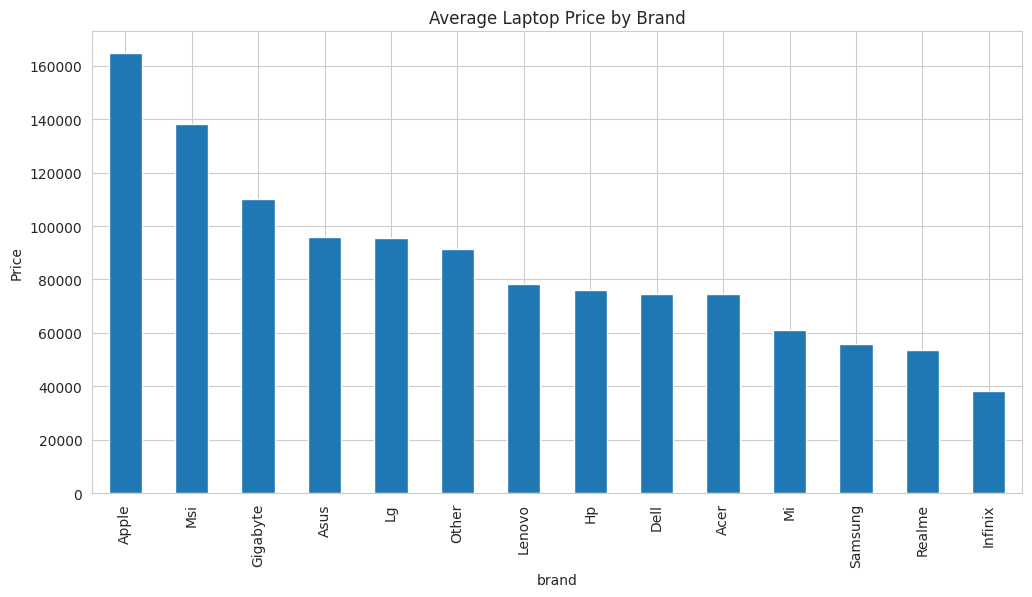

In [53]:
# Average price by brand
brand_price = (
    df_clean.groupby('brand')['price(in Rs.)']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
brand_price.plot(kind='bar')

plt.title('Average Laptop Price by Brand')
plt.ylabel('Price')
plt.show()

In [54]:
# Price to rating ratio by brand
import plotly.express as px

brand_stats = df_clean.groupby('brand').agg({
    'price(in Rs.)': 'mean',
    'rating': 'mean',
    'no_of_ratings': 'sum'
}).reset_index()

fig = px.scatter(
    brand_stats,
    x='price(in Rs.)',
    y='rating',
    size='no_of_ratings',
    color='brand',
    hover_name='brand',
    size_max=60,
    title='Price vs Rating by Brand',
    labels={
        'price(in Rs.)': 'Average Price',
        'rating': 'Average Rating',
        'no_of_ratings': 'Number of Ratings'
    }
)

fig.show()

## 6. Correlation Analysis

### Correlation Matrix

Main relationships identified:
- Strong correlation between number of reviews and ratings count
- Positive relationship between RAM and price
- Moderate relationship between price and rating

### Most Influential Features

Features with the strongest impact on ratings:
- RAM size
- Processor series
- Operating system
- Storage type

Features with weak influence:
- Number of reviews
- Screen size
- Storage size beyond 512 GB

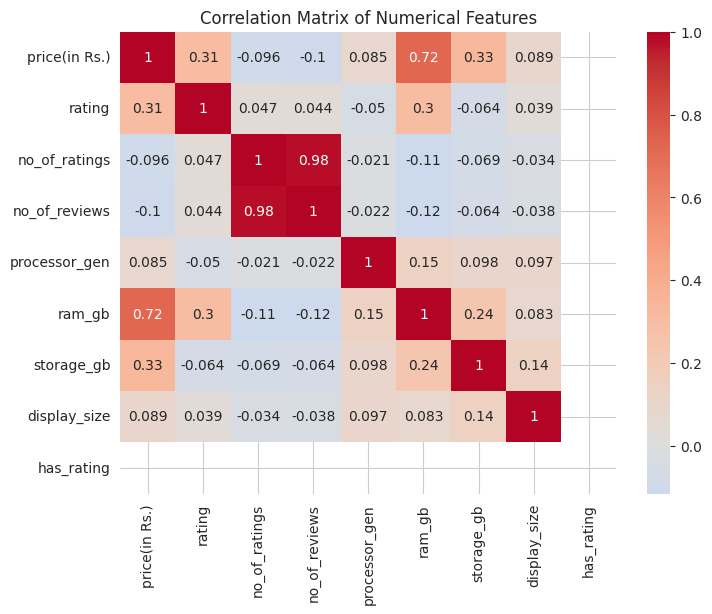

In [55]:
# Correlation
correlation_matrix = df_rated[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Correlation with rating
rating           1.000000
price(in Rs.)    0.311051
ram_gb           0.300906
no_of_ratings    0.047300
no_of_reviews    0.044392
display_size     0.038693
processor_gen   -0.049891
storage_gb      -0.063853
Name: rating, dtype: float64


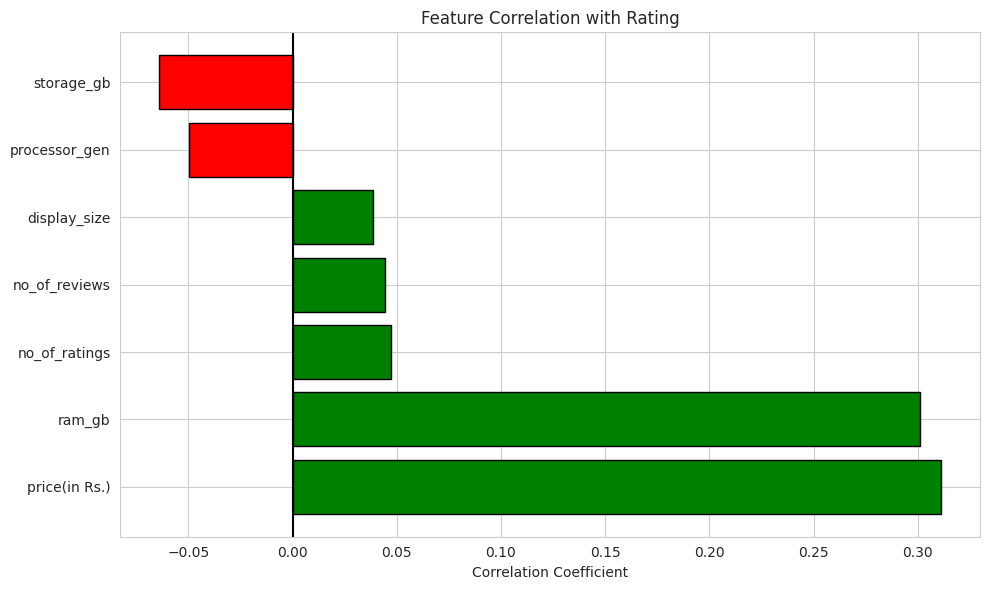

In [56]:
# Correlation of numerical features with rating
numeric_features = ['price(in Rs.)', 'ram_gb', 'storage_gb', 'display_size', 'processor_gen', 'no_of_ratings', 'no_of_reviews']
correlation = df_rated[numeric_features + ['rating']].corr()['rating'].sort_values(ascending=False)

print("Correlation with rating")
print(correlation)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in correlation[1:]]
ax.barh(correlation.index[1:], correlation[1:], color=colors, edgecolor='black')
ax.set_xlabel('Correlation Coefficient')
ax.set_title('Feature Correlation with Rating')
ax.axvline(x=0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

## 7. Business Insights
### Premium Segment

Typical high-rated premium laptop:
- macOS
- Apple M-series processor
- 16–32 GB RAM
- 512 GB SSD
- 13–14 inch display

### Mass-Market Recommendation
Optimal mainstream configuration:
- Windows 11
- Ryzen 5 / Intel i5
- 16 GB RAM
- 512 GB SSD
- 15.6 inch display

## 8. Final Conclusions
### Main Takeaways
- SSD storage is now the market standard.
- 16 GB RAM offers the best balance of performance and customer satisfaction.
- AMD processors demonstrate strong price-to-performance value.
- Premium ultrabooks consistently receive the highest user ratings.
- Storage size beyond 512 GB provides limited additional value for most users.

## 9. Future Improvements

Potential next steps:
- Build a machine learning model for rating prediction
- Perform clustering analysis
- Create an interactive dashboard using Streamlit
- Deploy the project as a web application
- Add automated preprocessing pipelines